<a href="https://colab.research.google.com/github/imdoamaral/ams_trabalho_final/blob/main/AMS_Trabalho_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantidade de inscritos por canal

In [15]:
import time, re
from googleapiclient.discovery import build
import pandas as pd
from google.colab import userdata

API_KEY = userdata.get('YOUTUBE_API_KEY')
if not API_KEY:
    raise RuntimeError("Variável YOUTUBE_API_KEY não encontrada nos Colab Secrets.")

youtube = build("youtube", "v3", developerKey=API_KEY)

CANAIS = {
    "luangameplay":      "UCddN6tViXZMEOfvO-rqfbNg",
    "fabiojunior":       "UC1WdbwLH7azQtv3BAnYt_vg",
    "diegosheipado":     "UC0Zhnj_IarrejROxchWtkMQ",
    "canaldoronaldinho": "UCjIN9CsGuLhj7NkNspZxw7g",
    "wallacegamer":      "UCb7JJAHkxdMVmFXw8tYDDdw",
    "renanplay":         "UCP-HJIRXN-apUPSCOehEDZw",
    "canaldocelinho":    "UCQj3EYemd3wu4ZO3J46qnjQ"
}

REGEX_NUM = re.compile(r"[^\d]")

def limpa_num(s):
    return int(REGEX_NUM.sub("", str(s)) or 0) if s else 0

print("Configurações iniciais carregadas com sucesso.")

Configurações iniciais carregadas com sucesso.


In [16]:
import time

resumo_canais = []

for apelido, canal_id in CANAIS.items():
    print(f"Coletando inscritos para: {apelido}")

    subs = youtube.channels().list(
        id=canal_id,
        part="statistics"
    ).execute()

    if subs.get("items") and len(subs["items"]) > 0:
        inscritos = limpa_num(subs["items"][0]["statistics"].get("subscriberCount"))
    else:
        inscritos = 0
        print(f"   Não foi possível obter o número de inscritos para {apelido}")

    resumo_canais.append({
        "Apelido": apelido,
        "Inscritos": inscritos,
    })
    time.sleep(1)

print("Coleta de inscritos dos canais concluída.")

Coletando inscritos para: luangameplay
Coletando inscritos para: fabiojunior
Coletando inscritos para: diegosheipado
Coletando inscritos para: canaldoronaldinho
Coletando inscritos para: wallacegamer
   Não foi possível obter o número de inscritos para wallacegamer
Coletando inscritos para: renanplay
Coletando inscritos para: canaldocelinho
   Não foi possível obter o número de inscritos para canaldocelinho
Coleta de inscritos dos canais concluída.


In [17]:
df_resumo = pd.DataFrame(resumo_canais)

df_resumo

,Apelido,Inscritos
0,luangameplay,1450000
1,fabiojunior,24700
2,diegosheipado,44500
3,canaldoronaldinho,99800
4,wallacegamer,0
5,renanplay,169000
6,canaldocelinho,0


# Análise exploratória

In [18]:
import pandas as pd

# Carrega dataset
df = pd.read_csv('/content/dataset_unificado.csv')
df['canal'] = df['canal'].astype(str).str.strip()

In [19]:
# Calcula o tamanho de cada mensagem (em caracteres)
df['tamanho_mensagem'] = df['mensagem'].str.len()

# Criação global de quantidade_mensagens
mensagens_por_live = df.groupby('id_video').size().reset_index(name='quantidade_mensagens')
canal_por_live = df[['id_video', 'canal']].drop_duplicates()
mensagens_por_live = mensagens_por_live.merge(canal_por_live, on='id_video')
mensagens_por_live = mensagens_por_live[mensagens_por_live['quantidade_mensagens'] > 0]
df = df.merge(mensagens_por_live[['id_video', 'quantidade_mensagens']], on='id_video', how='left')

## Estatísticas globais por transmissão



In [69]:
import pandas as pd

# 1. Calcular estatísticas para quantidade_mensagens
mean_quantidade_mensagens = mensagens_por_live['quantidade_mensagens'].mean()
median_quantidade_mensagens = mensagens_por_live['quantidade_mensagens'].median()

# 2. Calcular estatísticas para tamanho_mensagem
mean_tamanho_mensagem = df['tamanho_mensagem'].mean()
median_tamanho_mensagem = df['tamanho_mensagem'].median()

# 3. Calcular tempo_entre_mensagens
# Garante que 'timestamp' é datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Ordena por id_video e timestamp para calcular a diferença sequencial
df_sorted = df.sort_values(by=['id_video', 'timestamp'])

# Calcula a diferença de tempo entre mensagens consecutivas no mesmo vídeo
df_sorted['diff_timestamp'] = df_sorted.groupby('id_video')['timestamp'].diff()

# Converte as diferenças para segundos e ignora valores NaN resultantes do primeiro item de cada grupo
df_sorted['tempo_entre_mensagens_segundos'] = df_sorted['diff_timestamp'].dt.total_seconds().dropna()

# Filtra apenas as diferenças válidas (não NaN e não nulas)
tempo_entre_mensagens_validas = df_sorted[df_sorted['tempo_entre_mensagens_segundos'] > 0]['tempo_entre_mensagens_segundos']

# Calcula a média e mediana do tempo entre mensagens
mean_tempo_entre_mensagens = tempo_entre_mensagens_validas.mean()
median_tempo_entre_mensagens = tempo_entre_mensagens_validas.median()

# 4. Criar o DataFrame para a tabela
data_for_table = {
    'Variável': ['quantidade_mensagens', 'tamanho_mensagem', 'tempo_entre_mensagens'],
    'Média': [
        f'{mean_quantidade_mensagens:,.2f}'.replace('.', '#').replace(',', '.').replace('#', ','),
        f'{mean_tamanho_mensagem:,.2f}'.replace('.', '#').replace(',', '.').replace('#', ','),
        f'{mean_tempo_entre_mensagens:,.2f}'.replace('.', '#').replace(',', '.').replace('#', ',')
    ],
    'Mediana': [
        f'{median_quantidade_mensagens:,.2f}'.replace('.', '#').replace(',', '.').replace('#', ','),
        f'{median_tamanho_mensagem:,.2f}'.replace('.', '#').replace(',', '.').replace('#', ','),
        f'{median_tempo_entre_mensagens:,.2f}'.replace('.', '#').replace(',', '.').replace('#', ',')
    ]
}

df_stats = pd.DataFrame(data_for_table)

# 5. Exibir a tabela diretamente
display(df_stats)

,Variável,Média,Mediana
0,quantidade_mensagens,"7.535,52","2.171,00"
1,tamanho_mensagem,"40,39","18,00"
2,tempo_entre_mensagens,"1,54","0,38"


## CDF - Mensagens por Live

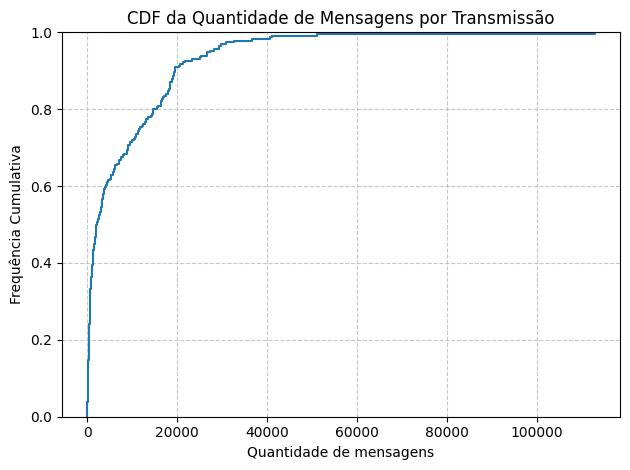

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.ecdfplot(data=mensagens_por_live, x='quantidade_mensagens')
plt.title("CDF da Quantidade de Mensagens por Transmissão")
plt.xlabel("Quantidade de mensagens")
plt.ylabel("Frequência Cumulativa")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("cdf_mensagens_por_live.png", dpi=300)
plt.show()

## Boxplot - Mensagens por Canal

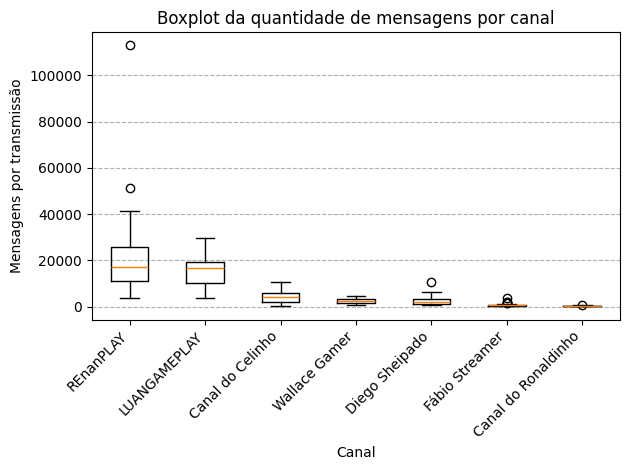

In [22]:
import matplotlib.pyplot as plt

canais = mensagens_por_live['canal'].unique()
dados_por_canal = [
    mensagens_por_live[mensagens_por_live['canal'] == canal]['quantidade_mensagens']
    for canal in canais
]
medianas = [dados_por_canal[i].median() for i in range(len(canais))]
canais_ordenados = [canais[i] for i in sorted(range(len(medianas)), key=lambda x: medianas[x], reverse=True)]
dados_ordenados = [dados_por_canal[i] for i in sorted(range(len(medianas)), key=lambda x: medianas[x], reverse=True)]
plt.boxplot(dados_ordenados, tick_labels=canais_ordenados)
plt.title("Boxplot da quantidade de mensagens por canal")
plt.xlabel("Canal")
plt.ylabel("Mensagens por transmissão")
# plt.ylim(0, 20000)  # Limita o eixo Y para melhorar a visualização dos canais menores
plt.grid(axis='y', linestyle='dashed')
plt.grid(axis='x', visible=False)
plt.xticks(ticks=range(1, len(canais_ordenados) + 1), labels=canais_ordenados, rotation=45, ha='right', va='top')
plt.tight_layout()
plt.savefig("boxplot_mensagens_por_canal.png", dpi=300)

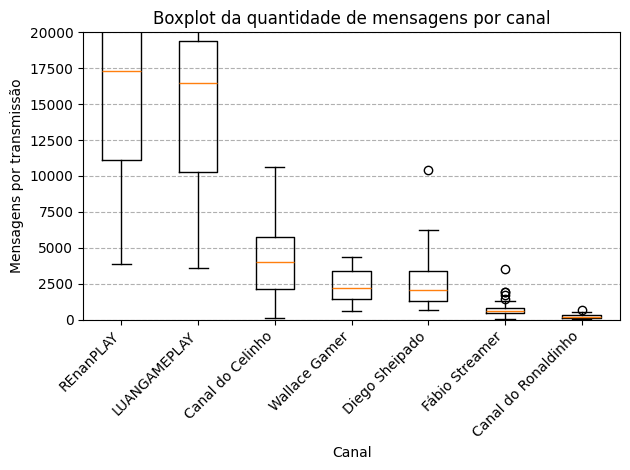

In [23]:
import matplotlib.pyplot as plt

canais = mensagens_por_live['canal'].unique()
dados_por_canal = [
    mensagens_por_live[mensagens_por_live['canal'] == canal]['quantidade_mensagens']
    for canal in canais
]
medianas = [dados_por_canal[i].median() for i in range(len(canais))]
canais_ordenados = [canais[i] for i in sorted(range(len(medianas)), key=lambda x: medianas[x], reverse=True)]
dados_ordenados = [dados_por_canal[i] for i in sorted(range(len(medianas)), key=lambda x: medianas[x], reverse=True)]
plt.boxplot(dados_ordenados, tick_labels=canais_ordenados)
plt.title("Boxplot da quantidade de mensagens por canal")
plt.xlabel("Canal")
plt.ylabel("Mensagens por transmissão")
plt.ylim(0, 20000)  # Limita o eixo Y para melhorar a visualização dos canais menores
plt.grid(axis='y', linestyle='dashed')
plt.grid(axis='x', visible=False)
plt.xticks(ticks=range(1, len(canais_ordenados) + 1), labels=canais_ordenados, rotation=45, ha='right', va='top')
plt.tight_layout()
plt.savefig("boxplot_mensagens_por_canal.png", dpi=300)

## Dispersão - Correlação entre Inscritos x Média de mensanges por transmissão

Média de mensagens por canal (alinhado): [15205.31428571   723.34545455  2583.26315789   228.78787879
 20518.72916667]


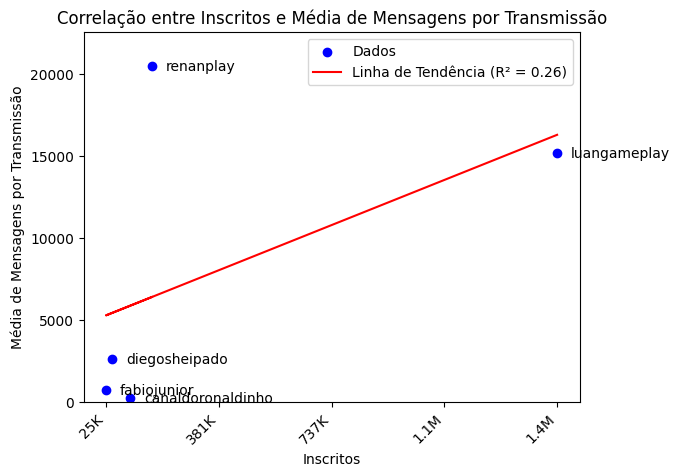

In [24]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# Apelidos dos canais que queremos plotar e seus inscritos correspondentes
canais_plot_apelidos = ["luangameplay", "fabiojunior", "diegosheipado", "canaldoronaldinho", "renanplay"]
inscritos_plot_values = [1450000, 24700, 44500, 99800, 169000]

# Estabelece um mapeamento dos apelidos (e.g., 'luangameplay') para os nomes reais dos canais em `df['canal']`
apelido_to_df_channel_name_map = {
    "luangameplay": "LUANGAMEPLAY",
    "fabiojunior": "Fábio Streamer",
    "diegosheipado": "Diego Sheipado",
    "canaldoronaldinho": "Canal do Ronaldinho",
    "renanplay": "REnanPLAY",
}

# Calcula a média de mensagens por transmissão usando os nomes reais dos canais de `mensagens_por_live`
mean_messages_raw = mensagens_por_live.groupby('canal')['quantidade_mensagens'].mean().reset_index()
mean_messages_raw.rename(columns={'canal': 'df_channel_name', 'quantidade_mensagens': 'mean_messages'}, inplace=True)

# Cria um DataFrame temporário para o mapeamento dos apelidos para os nomes do DataFrame
mapping_df = pd.DataFrame(list(apelido_to_df_channel_name_map.items()), columns=['Apelido', 'df_channel_name'])

# Une para alinhar as médias de mensagens com os apelidos
merged_plot_data = pd.merge(
    mapping_df,
    mean_messages_raw,
    on='df_channel_name',
    how='left' # Usar left join para manter todos os apelidos desejados
)

# Garante que a ordem dos dados corresponda à lista `canais_plot_apelidos` para `linregress`
merged_plot_data = merged_plot_data.set_index('Apelido').reindex(canais_plot_apelidos).reset_index()

# Extrai os valores finais de `mensagens_media` e `inscritos` na ordem correta
mensagens_media_plot_values = merged_plot_data['mean_messages'].fillna(0).values

# Verifica os valores calculados
print("Média de mensagens por canal (alinhado):", mensagens_media_plot_values)

# Realiza regressão linear para linha de tendência
slope, intercept, r_value, p_value, std_err = linregress(inscritos_plot_values, mensagens_media_plot_values)
line = slope * np.array(inscritos_plot_values) + intercept

# Cria o gráfico de dispersão
plt.figure()
plt.scatter(inscritos_plot_values, mensagens_media_plot_values, color='blue', label='Dados')
plt.plot(inscritos_plot_values, line, color='red', label=f'Linha de Tendência (R² = {r_value**2:.2f})')

# Configurações do gráfico
plt.xlabel('Inscritos')
plt.ylabel('Média de Mensagens por Transmissão')
plt.title('Correlação entre Inscritos e Média de Mensagens por Transmissão')
plt.legend()
plt.grid(False)

# Adiciona rótulos aos pontos
for i, canal_apelido in enumerate(canais_plot_apelidos):
    plt.annotate(canal_apelido, (inscritos_plot_values[i], mensagens_media_plot_values[i]), xytext=(10, -3), textcoords='offset points')

# Ajusta escalas para melhor visualização (ticks do eixo X dinâmicos)
x_ticks_locs = np.linspace(min(inscritos_plot_values), max(inscritos_plot_values), 5)
x_ticks_labels = [f'{x/1000:,.0f}K' if x < 1_000_000 else f'{x/1_000_000:,.1f}M' for x in x_ticks_locs]
plt.xticks(x_ticks_locs, x_ticks_labels, rotation=45, ha='right')

plt.ylim(0, max(mensagens_media_plot_values) * 1.1 if max(mensagens_media_plot_values) > 0 else 30000)

# Salva o gráfico
plt.savefig('correlacao_inscritos_mensagens.png', dpi=300, bbox_inches='tight')
plt.show()

## Wordcloud

In [32]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download de recursos do NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

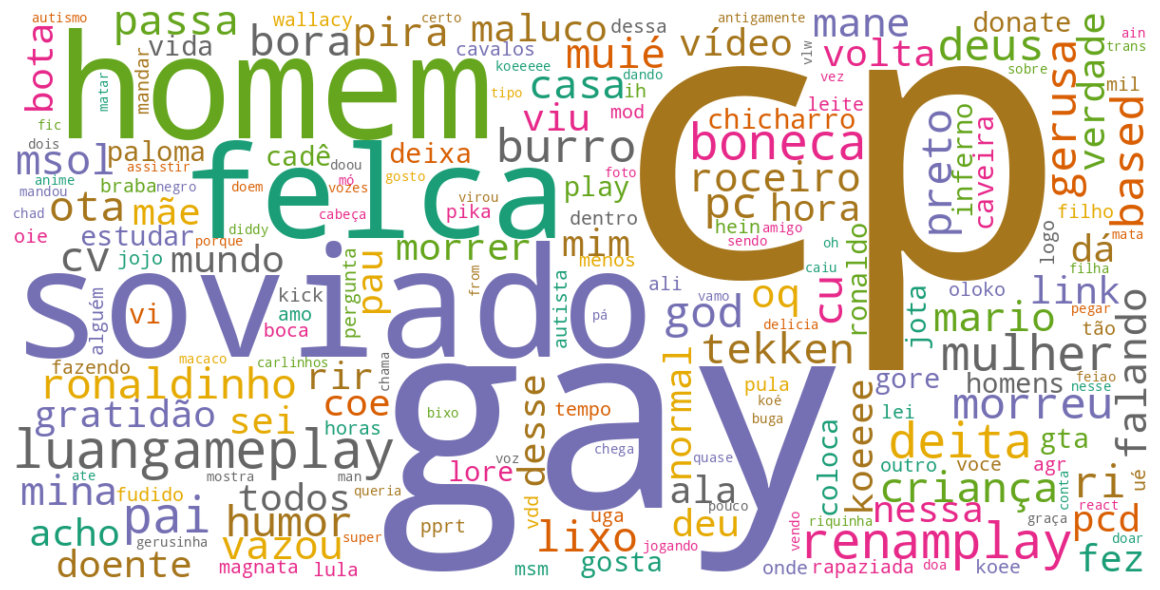

In [34]:
from wordcloud import WordCloud
import re

# Carrega a lista padrão de stopwords do NLTK.
stop_words = set(stopwords.words('portuguese'))

# CATEGORIA 1: Conectivos e Palavras de Ligação (Artigos, Preposições, etc.)
stopwords_conectivos = [
    'pra', 'pro', 'pa', 'q', 'so', 'la', 'lá', 'aí', 'ai', 'entao', 'então', 'assim',
    'aqui', 'tudo', 'nada', 'coisa', 'coisas', 'todo', 'toda'
]

# CATEGORIA 2: Verbos Comuns e Conjugações
stopwords_verbos = [
    'ser', 'fazer', 'ir', 'ter', 'dar', 'ver', 'quer', 'dizer', 'falar', 'saber',
    'ficar', 'poder', 'parecer', 'achar', 'comer', 'jogar', 'manda', 'tira', 'pega',
    'vem', 'sai', 'deve', 'acha', 'faz', 'vai', 'tá', 'ta', 'to', 'tô', 'ia', 'era',
    'foi', 'vou', 'falou', 'ficou', 'tava', 'ficar', 'falaro', 'olha', 'toma',
    'parece', 'fala', 'pode', 'come', 'fica', 'sabe', 'quero', 'joga'
]

# CATEGORIA 3: Adjetivos, Advérbios e Qualificadores Genéricos
stopwords_adjetivos_adverbios = [
    'bom', 'boa', 'ruim', 'melhor', 'pior', 'maior', 'menor', 'novo', 'real', 'igual',
    'bem', 'mal', 'agora', 'hoje', 'hj', 'ainda', 'nunca', 'sempre', 'demais', 'cedo',
    'noite', 'dia', 'anos', 'quanto', 'linda', 'gostoso', 'podre', 'cade',
    'ja' # <--- MOVIDA DA CAT 1
]

# CATEGORIA 4: Interjeições, Saudações e Gírias de Interação
stopwords_interjeicoes_girias = [
    'oi', 'opa', 'eita', 'ah', 'oxi', 'oops', 'sim', 'nao', 'mano', 'cara', 'mané',
    'mlk', 'brabo', 'salve', 'né', 'ne', 'vc', 'mt', 'pq', 'po', 'koe', 'koeee', 'ae',
    'mds', 'tbm', 'gente'
]

# CATEGORIA 5: Ofensas e Palavrões Comuns
stopwords_ofensas = [
    'pqp', 'porra', 'merda', 'caralho', 'poha', 'fds', 'krl', 'foda', 'lixeiro'
]

# CATEGORIA 6: Palavras de Contexto (REMOÇÃO ESTRATÉGICA)
stopwords_contexto_geral = [
    'live', 'jogo', 'jogos', 'games', 'chat', 'video', 'canal', 'ban'
]
stopwords_contexto_topicos = [
    'filme', 'filmin', 'música', 'musica', 'dinheiro', 'reais', 'medo'
]
stopwords_contexto_streamers = [
    'renan', 'luan', 'renanplay', 'biah', 'cavalo', 'sheipado', 'sheypado',
    'shey', 'shei', 'manso', 'nobre', 'pesco', 'rica', 'cioba', 'tapa', 'américa'
]

# CATEGORIA 7: Miscelânea e Termos em Outros Idiomas
stopwords_misc = [
    'https', 'the', 'of', 'resto', 'calma', 'nome'
]

# Junta todas as listas de categorias em uma única lista final.
custom_stop_words = (
    stopwords_conectivos +
    stopwords_verbos +
    stopwords_adjetivos_adverbios +
    stopwords_interjeicoes_girias +
    stopwords_ofensas +
    stopwords_contexto_geral +
    stopwords_contexto_topicos +
    stopwords_contexto_streamers +
    stopwords_misc
)

# Adiciona a sua lista customizada ao conjunto principal de stopwords do NLTK.
# Usar 'update' em um 'set' já garante que não haverá palavras duplicadas.
stop_words.update(custom_stop_words)

texto_completo = ' '.join(df['mensagem'].dropna().astype(str).tolist())
palavras = word_tokenize(texto_completo.lower())

palavras_filtradas = []
for palavra in palavras:
    if re.fullmatch(r'k{2,}', palavra):
        continue

    if palavra.isalpha() and len(palavra) > 1 and palavra not in stop_words:
        palavras_filtradas.append(palavra)

# Geração da WordCloud
frequencia_palavras = nltk.FreqDist(palavras_filtradas)
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    min_font_size=10,
    colormap='Dark2'
).generate_from_frequencies(frequencia_palavras)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()

In [35]:
import pandas as pd

print(f"Total de {len(custom_stop_words)} palavras adicionadas.\n")

print("10 palavras mais frequentes (após a limpeza final):\n")
df_frequencia = pd.DataFrame(frequencia_palavras.most_common(10), columns=['Palavra', 'Frequência'])
print(df_frequencia.to_markdown(index=False))

Total de 168 palavras adicionadas.

10 palavras mais frequentes (após a limpeza final):

| Palavra      |   Frequência |
|:-------------|-------------:|
| cp           |        15779 |
| gay          |         5839 |
| soviado      |         5329 |
| homem        |         4830 |
| felca        |         4785 |
| luangameplay |         4503 |
| renamplay    |         4100 |
| pai          |         4001 |
| boneca       |         3976 |
| mulher       |         3841 |


## Teste de Distribuição

In [30]:
!pip install fitter

             sumsquare_error           aic           bic    kl_div  \
lognorm         6.087454e-09  2.723606e+03  2.733933e+03       inf   
weibull_min     7.119804e-09  2.854499e+03  2.864826e+03       inf   
expon           5.791525e-08  3.292131e+03  3.299016e+03       inf   
norm            1.072758e-07  4.623532e+03  4.630417e+03       inf   
gamma           1.383471e-07  2.609697e+06  2.609707e+06  0.953781   

             ks_statistic     ks_pvalue  
lognorm          0.091872  3.795734e-02  
weibull_min      0.151515  4.279677e-05  
expon            0.265330  7.613837e-15  
norm             0.258905  3.806688e-14  
gamma            0.995663  0.000000e+00  
Melhor distribuição: {'lognorm': {'s': 1.8644370539217807, 'loc': 18.020768659437703, 'scale': 2135.8105633004716}}


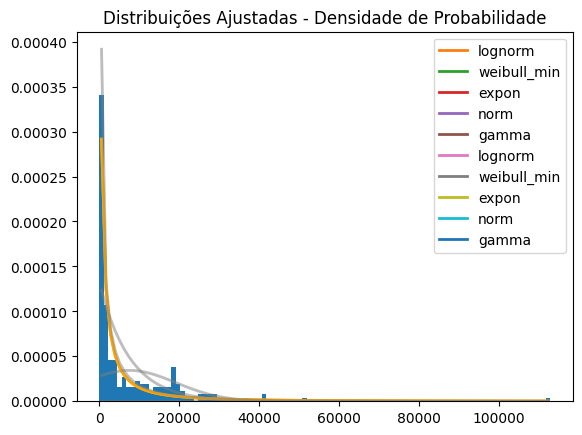

In [31]:
# FITTER - TESTE DE DISTRIBUIÇÃO
import matplotlib.pyplot as plt
from fitter import Fitter

data = mensagens_por_live['quantidade_mensagens'].dropna()

# Criando o objeto Fitter com distribuições comuns a serem testadas
f = Fitter(data, distributions=['norm', 'lognorm', 'expon', 'gamma', 'weibull_min'])

# Ajustando as distribuições aos dados
f.fit()

# Exibindo o resumo com as melhores distribuições
print(f.summary())

# Exibindo a melhor distribuição encontrada
print(f"Melhor distribuição: {f.get_best()}")

# Gerando o gráfico da função de densidade de probabilidade
f.plot_pdf()
plt.title('Distribuições Ajustadas - Densidade de Probabilidade')

# Obtendo os eixos e destacando a distribuição lognormal
axes = plt.gcf().get_axes()
for ax in axes:
    for line in ax.get_lines():
        label = line.get_label()
        if 'lognorm' in label.lower():
            line.set_color('orange')  # Destaca lognormal em azul
            line.set_linewidth(2)   # Aumenta a espessura
        else:
            line.set_color('gray')  # Outras em cinza
            line.set_alpha(0.3)     # Reduz opacidade

plt.grid(False)  # Remove os grids
plt.savefig('distribuicao_teorica_quantidade_mensagens.png', dpi=300, bbox_inches='tight')

## Análise Temporal (Hora do Dia e Dia da Semana)

Explora os padrões de envio de mensagens por hora do dia e por dia da semana para entender quando cada canal tem maior engajamento.


In [36]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['hora'] = df['timestamp'].dt.hour

dias_da_semana = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
df['dia_semana'] = df['timestamp'].dt.dayofweek.map(lambda x: dias_da_semana[x])

print("Colunas 'hora' e 'dia_semana' criadas com sucesso.")
print(df[['timestamp', 'hora', 'dia_semana']].head())

Colunas 'hora' e 'dia_semana' criadas com sucesso.
                         timestamp  hora    dia_semana
0 2025-07-09 22:07:31.917913+00:00    22  Quarta-feira
1 2025-07-09 22:07:37.620879+00:00    22  Quarta-feira
2 2025-07-09 22:08:13.924824+00:00    22  Quarta-feira
3 2025-07-09 22:08:18.448003+00:00    22  Quarta-feira
4 2025-07-09 22:08:18.642011+00:00    22  Quarta-feira


In [37]:
df_hourly_avg = df.groupby(['canal', 'hora']).size().reset_index(name='quantidade_mensagens')
df_hourly_avg = df_hourly_avg.groupby(['canal', 'hora'])['quantidade_mensagens'].mean().reset_index()
print("Média de mensagens por hora por canal calculada com sucesso.")
print(df_hourly_avg.head())

Média de mensagens por hora por canal calculada com sucesso.
              canal  hora  quantidade_mensagens
0  Canal do Celinho     0                1907.0
1  Canal do Celinho     1               12287.0
2  Canal do Celinho     2               19517.0
3  Canal do Celinho     3               17642.0
4  Canal do Celinho     4                8784.0


In [38]:
df_daily_avg = df.groupby(['canal', 'dia_semana']).size().reset_index(name='quantidade_mensagens')

day_order_map = {name: i for i, name in enumerate(dias_da_semana)}
df_daily_avg['dia_semana_num'] = df_daily_avg['dia_semana'].map(day_order_map)
df_daily_avg = df_daily_avg.sort_values(by=['canal', 'dia_semana_num'])
df_daily_avg = df_daily_avg.groupby(['canal', 'dia_semana', 'dia_semana_num'])['quantidade_mensagens'].mean().reset_index()

print("Média de mensagens por dia da semana por canal calculada com sucesso.")
print(df_daily_avg.head())


Média de mensagens por dia da semana por canal calculada com sucesso.
              canal     dia_semana  dia_semana_num  quantidade_mensagens
0  Canal do Celinho        Domingo               6               16781.0
1  Canal do Celinho   Quarta-feira               2                2500.0
2  Canal do Celinho   Quinta-feira               3               11734.0
3  Canal do Celinho  Segunda-feira               0                8752.0
4  Canal do Celinho    Sexta-feira               4                7950.0


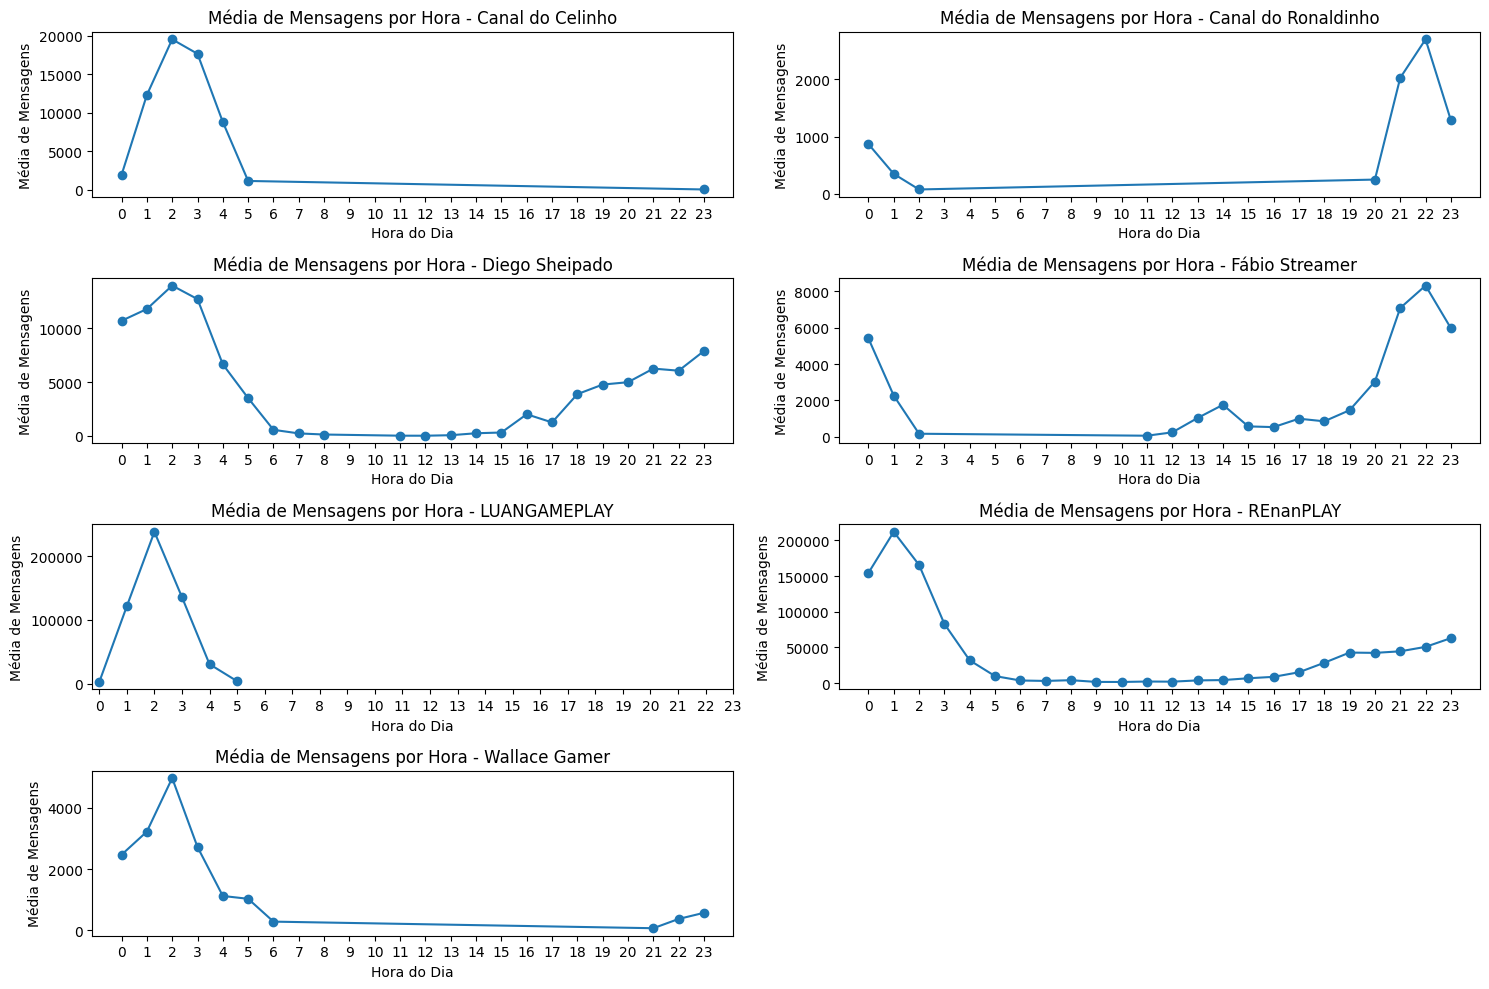

Gráficos de média de mensagens por hora por canal gerados com sucesso e salvos.


In [57]:
# MÉDIA DE MENSAGENS POR HORA POR CANAL

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
channels = df_hourly_avg['canal'].unique()

for i, canal in enumerate(channels):
    plt.subplot(len(channels) // 2 + len(channels) % 2, 2, i + 1)
    channel_data = df_hourly_avg[df_hourly_avg['canal'] == canal]
    plt.plot(channel_data['hora'], channel_data['quantidade_mensagens'], marker='o')
    plt.title(f'Média de Mensagens por Hora - {canal}')
    plt.xlabel('Hora do Dia')
    plt.ylabel('Média de Mensagens')
    plt.xticks(range(0, 24))
    plt.grid(False)

plt.tight_layout()
plt.savefig('hourly_messages_per_channel.png', dpi=300)
plt.show()
print("Gráficos de média de mensagens por hora por canal gerados com sucesso e salvos.")

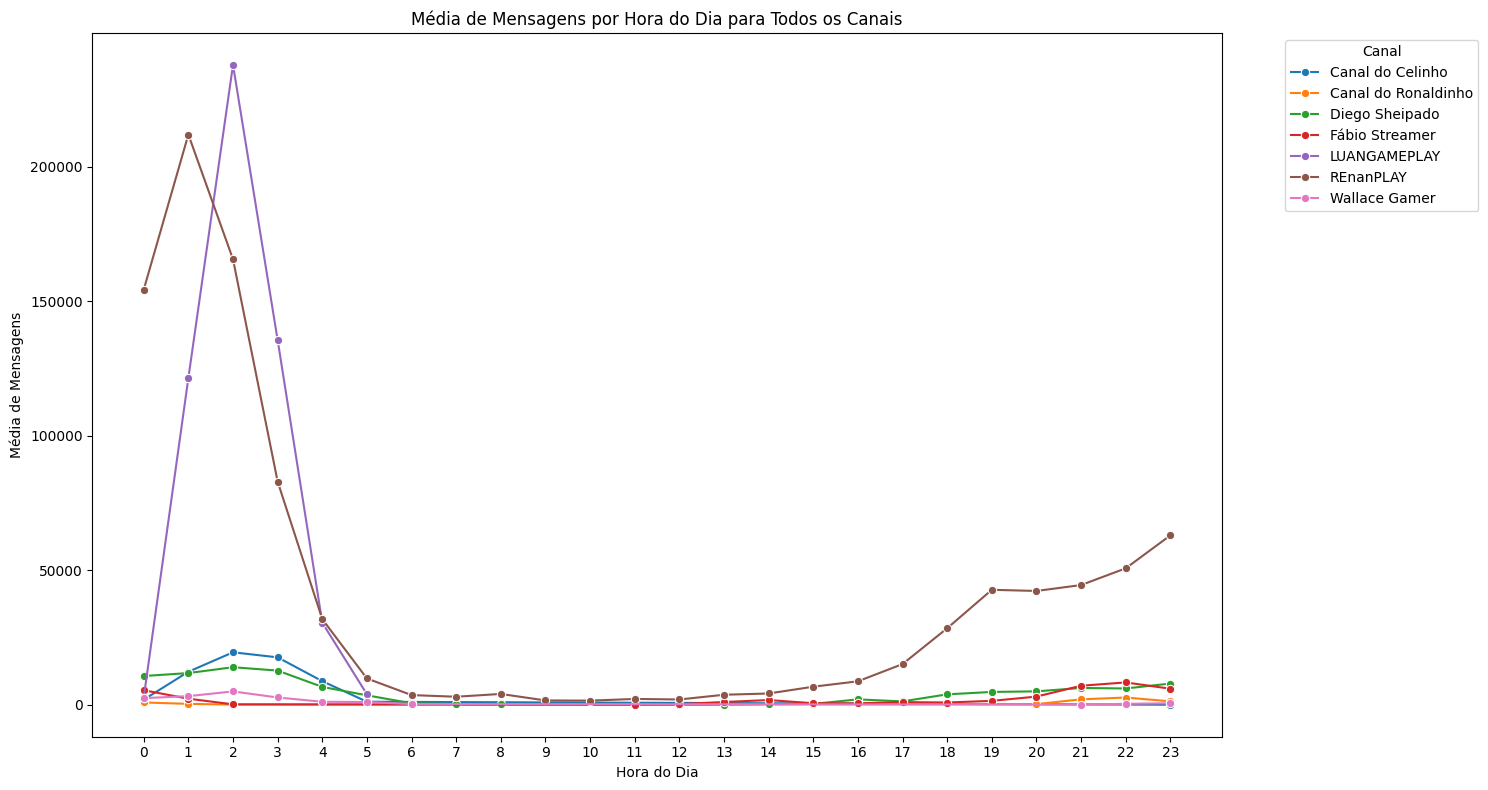

Gráfico de média de mensagens por hora para todos os canais gerado com sucesso e salvo.


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# MÉDIA DE MENSAGENS POR HORA POR CANAL (GRÁFICO ÚNICO)

plt.figure(figsize=(15, 8))
channels = df_hourly_avg['canal'].unique()

for canal in channels:
    channel_data = df_hourly_avg[df_hourly_avg['canal'] == canal]
    sns.lineplot(x='hora', y='quantidade_mensagens', data=channel_data, marker='o', label=canal)

plt.title('Média de Mensagens por Hora do Dia para Todos os Canais')
plt.xlabel('Hora do Dia')
plt.ylabel('Média de Mensagens')
plt.xticks(range(0, 24)) # Garante que todas as horas sejam exibidas
plt.grid(False)
plt.legend(title='Canal', bbox_to_anchor=(1.05, 1), loc='upper left') # Coloca a legenda fora do gráfico
plt.tight_layout()
plt.savefig('hourly_messages_all_channels.png', dpi=300)
plt.show()
print("Gráfico de média de mensagens por hora para todos os canais gerado com sucesso e salvo.")

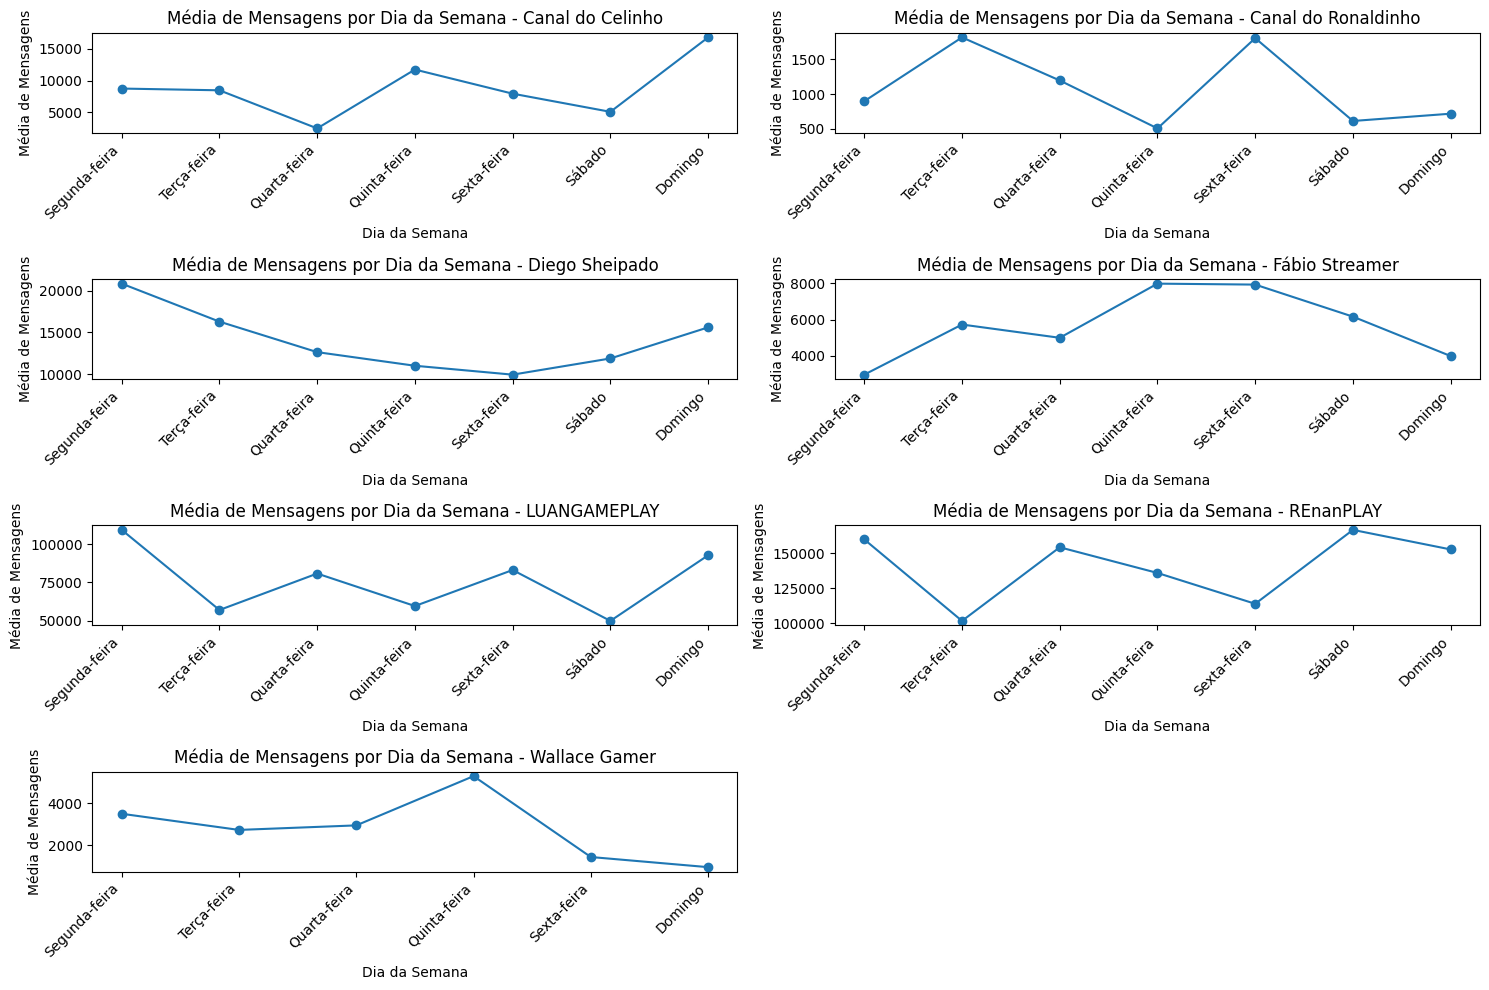

Gráficos de média de mensagens por dia da semana por canal gerados com sucesso e salvos.


In [63]:
# MÉDIA DE MENSAGENS POR DIA DA SEMANA POR CANAL

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
channels = df_daily_avg['canal'].unique()

for i, canal in enumerate(channels):
    plt.subplot(len(channels) // 2 + len(channels) % 2, 2, i + 1)
    channel_data = df_daily_avg[df_daily_avg['canal'] == canal]
    channel_data = channel_data.sort_values('dia_semana_num')
    plt.plot(channel_data['dia_semana'], channel_data['quantidade_mensagens'], marker='o')
    plt.title(f'Média de Mensagens por Dia da Semana - {canal}')
    plt.xlabel('Dia da Semana')
    plt.ylabel('Média de Mensagens')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('daily_messages_per_channel.png', dpi=300)
plt.show()
print("Gráficos de média de mensagens por dia da semana por canal gerados com sucesso e salvos.")

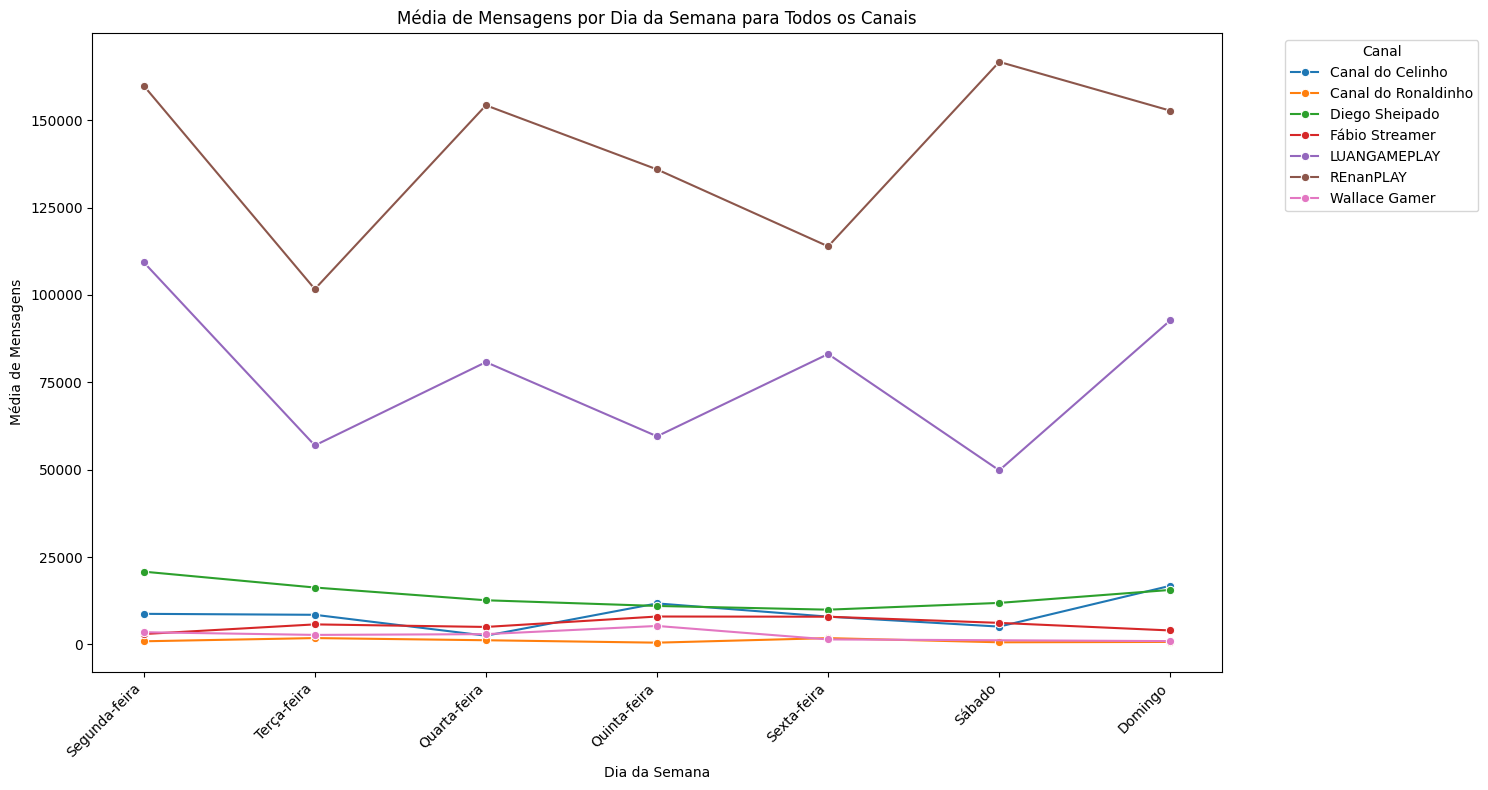

Gráfico de média de mensagens por dia da semana para todos os canais gerado com sucesso e salvo.


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# MÉDIA DE MENSAGENS POR DIA DA SEMANA POR CANAL (GRÁFICO ÚNICO)

plt.figure(figsize=(15, 8))
channels = df_daily_avg['canal'].unique()

dias_da_semana = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
day_order_map = {name: i for i, name in enumerate(dias_da_semana)}

df_daily_avg['dia_semana_num'] = df_daily_avg['dia_semana'].map(day_order_map)
df_daily_avg_sorted = df_daily_avg.sort_values(by=['canal', 'dia_semana_num'])

for canal in channels:
    channel_data = df_daily_avg_sorted[df_daily_avg_sorted['canal'] == canal]
    sns.lineplot(x='dia_semana', y='quantidade_mensagens', data=channel_data, marker='o', label=canal)

plt.title('Média de Mensagens por Dia da Semana para Todos os Canais')
plt.xlabel('Dia da Semana')
plt.ylabel('Média de Mensagens')
plt.xticks(rotation=45, ha='right')
plt.grid(False)
plt.legend(title='Canal', bbox_to_anchor=(1.05, 1), loc='upper left') # Coloca a legenda fora do gráfico
plt.tight_layout()
plt.savefig('daily_messages_all_channels.png', dpi=300)
plt.show()
print("Gráfico de média de mensagens por dia da semana para todos os canais gerado com sucesso e salvo.")